<a href="https://colab.research.google.com/github/Anushika1234/AI-Driven-Project-Timeline-Forecasting-for-Defence-R-D/blob/model-1/DRDOtask1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [ ]:
# Replace with the actual file path if different
df = pd.read_excel("/content/Closed_Project_new_180725.xlsx")

# Preview the dataset
print(df.head())


   S.No Project Title   Lab Cluster Date of Sanction Initial PDC   Final PDC  \
0     1           A58  ARDE     ACE       03-04-2017  03-04-2019  31-03-2021   
1     2           A68  ARDE     ACE       06-12-2016  05-12-2018  30-06-2021   
2     3           A71  ARDE     ACE       08-11-2016  07-11-2020  06-11-2023   
3     4           A72  ARDE     ACE       03-11-2016  02-11-2018  30-06-2021   
4     5           A77  ARDE     ACE       25-08-2016  24-08-2019  24-08-2019   

   Initial Cost  Final Cost (Rs. in Cr.) Category  No. of PDCs  
0         22.89                    22.89       UT            3  
1         41.98                    41.98       PS            3  
2         13.90                    13.90       PS            2  
3         71.00                    91.00       PS            3  
4          9.21                     9.21       ST            0  


In [ ]:
# Drop any irrelevant or identifier columns (like project title if not meaningful)
df_clean = df.drop(columns=['Project Title'], errors='ignore')  # if applicable

# Drop missing target values
df_clean = df_clean.dropna(subset=['Final PDC'])

# Separate features and target
X = df_clean.drop(columns=['Final PDC'])
y = df_clean['Final PDC']

# Ensure all data is numeric
X = X.apply(pd.to_numeric, errors='coerce')
X = X.fillna(0)  # or you can use better imputation


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)


In [ ]:
svm = SVR(kernel='rbf')
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)


In [ ]:
xgb = XGBRegressor(n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)


In [ ]:
def evaluate_model(name, y_test, y_pred):
    print(f"\n📊 {name} Evaluation:")
    print("MAE :", mean_absolute_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("R²  :", r2_score(y_test, y_pred))

evaluate_model("Random Forest", y_test, y_pred_rf)
evaluate_model("SVR", y_test, y_pred_svm)
evaluate_model("XGBoost", y_test, y_pred_xgb)



📊 Random Forest Evaluation:
MAE : 372.94881481481485
RMSE: 631.520441788147
R²  : 0.9469327777363763

📊 SVR Evaluation:
MAE : 2263.352855352921
RMSE: 2711.88475563239
R²  : 0.021425286195921434

📊 XGBoost Evaluation:
MAE : 370.0804748535156
RMSE: 589.921393068602
R²  : 0.9536937475204468


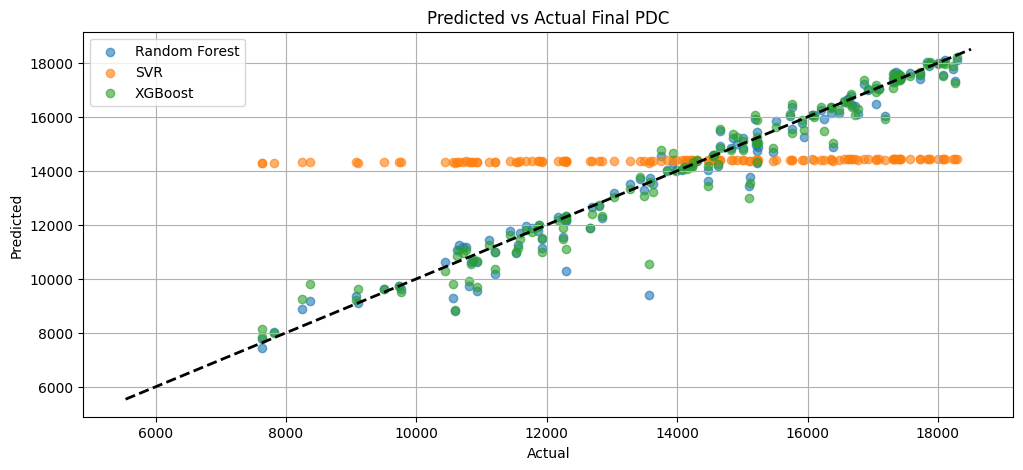

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.scatter(y_test, y_pred_rf, label='Random Forest', alpha=0.6)
plt.scatter(y_test, y_pred_svm, label='SVR', alpha=0.6)
plt.scatter(y_test, y_pred_xgb, label='XGBoost', alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual Final PDC")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model_cv(model, X, y, model_name="Model"):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    mae_scores = -cross_val_score(model, X, y, cv=kf, scoring='neg_mean_absolute_error')
    rmse_scores = np.sqrt(-cross_val_score(model, X, y, cv=kf, scoring='neg_mean_squared_error'))
    r2_scores = cross_val_score(model, X, y, cv=kf, scoring='r2')

    print(f"\n📊 {model_name} Cross-Validation Results:")
    print(f"Mean MAE: {mae_scores.mean():.2f}")
    print(f"Mean RMSE: {rmse_scores.mean():.2f}")
    print(f"Mean R²: {r2_scores.mean():.2f}")


In [ ]:
evaluate_model_cv(RandomForestRegressor(random_state=42), X, y, "Random Forest")
evaluate_model_cv(SVR(), X, y, "SVR")
evaluate_model_cv(XGBRegressor(random_state=42), X, y, "XGBoost")



📊 Random Forest Cross-Validation Results:
Mean MAE: 278.67
Mean RMSE: 426.55
Mean R²: 0.97

📊 SVR Cross-Validation Results:
Mean MAE: 2143.79
Mean RMSE: 2702.95
Mean R²: -0.01

📊 XGBoost Cross-Validation Results:
Mean MAE: 283.68
Mean RMSE: 433.54
Mean R²: 0.97


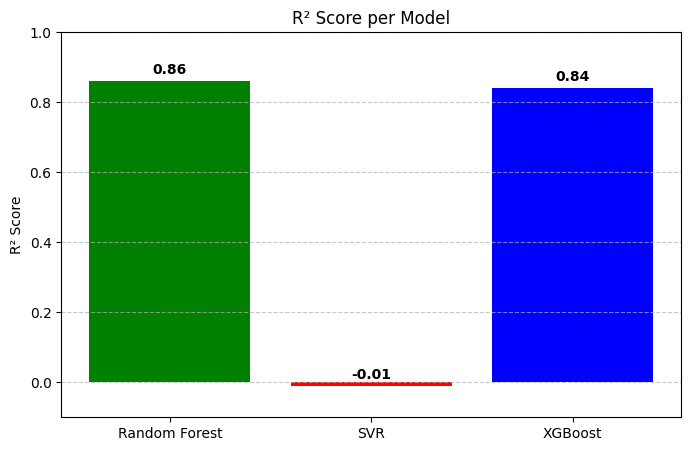

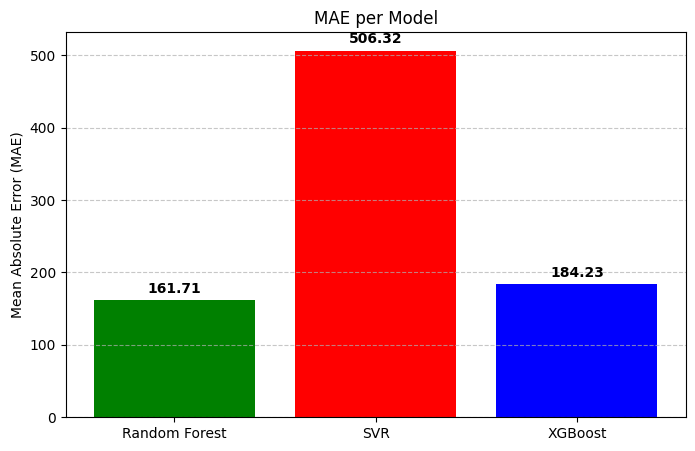

In [ ]:
import matplotlib.pyplot as plt

# Model names and metrics
models = ['Random Forest', 'SVR', 'XGBoost']
r2_scores = [0.86, -0.01, 0.84]
mae_scores = [161.71, 506.32, 184.23]

# Bar chart for R² scores
plt.figure(figsize=(8, 5))
plt.bar(models, r2_scores, color=['green', 'red', 'blue'])
plt.title('R² Score per Model')
plt.ylabel('R² Score')
plt.ylim(-0.1, 1.0)
for i, v in enumerate(r2_scores):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Bar chart for MAE scores
plt.figure(figsize=(8, 5))
plt.bar(models, mae_scores, color=['green', 'red', 'blue'])
plt.title('MAE per Model')
plt.ylabel('Mean Absolute Error (MAE)')
for i, v in enumerate(mae_scores):
    plt.text(i, v + 10, f"{v:.2f}", ha='center', fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [ ]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

xgb = XGBRegressor(random_state=42)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid,
                           cv=5, scoring='r2', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

print("✅ Best XGBoost Parameters:", grid_search.best_params_)
print("📈 Best R² score on validation set:", grid_search.best_score_)
best_model = grid_search.best_estimator_


Fitting 5 folds for each of 36 candidates, totalling 180 fits
✅ Best XGBoost Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
📈 Best R² score on validation set: 0.9789105415344238


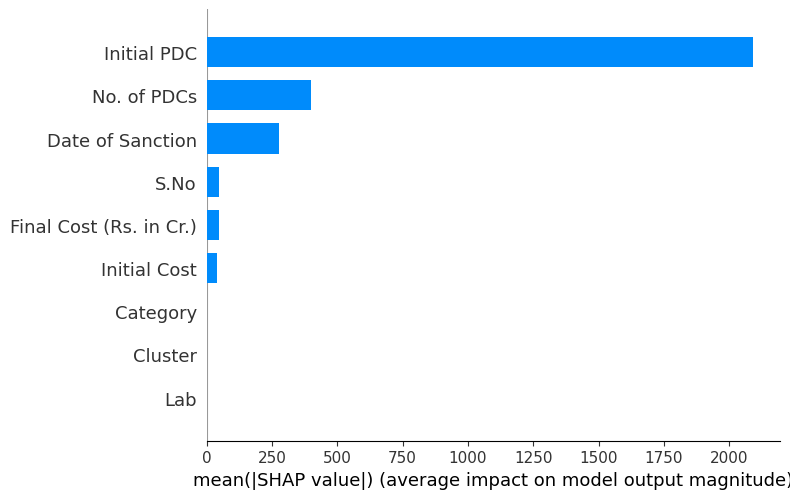

XGBoostError: [09:27:41] /workspace/src/c_api/c_api_utils.h:127: Check failed: std::accumulate(shape.cbegin(), shape.cend(), static_cast<bst_ulong>(1), std::multiplies<>{}) == chunksize * rows (18 vs. 90) : 
Stack trace:
  [bt] (0) /usr/local/lib/python3.11/dist-packages/xgboost/lib/libxgboost.so(+0x25c1ac) [0x7e9598e5c1ac]
  [bt] (1) /usr/local/lib/python3.11/dist-packages/xgboost/lib/libxgboost.so(+0x264f71) [0x7e9598e64f71]
  [bt] (2) /usr/local/lib/python3.11/dist-packages/xgboost/lib/libxgboost.so(XGBoosterPredictFromDMatrix+0x3e5) [0x7e9598d6a215]
  [bt] (3) /lib/x86_64-linux-gnu/libffi.so.8(+0x7e2e) [0x7e9605ea7e2e]
  [bt] (4) /lib/x86_64-linux-gnu/libffi.so.8(+0x4493) [0x7e9605ea4493]
  [bt] (5) /usr/lib/python3.11/lib-dynload/_ctypes.cpython-311-x86_64-linux-gnu.so(+0xa4d8) [0x7e96061084d8]
  [bt] (6) /usr/lib/python3.11/lib-dynload/_ctypes.cpython-311-x86_64-linux-gnu.so(+0x9c8e) [0x7e9606107c8e]
  [bt] (7) /usr/bin/python3(_PyObject_MakeTpCall+0x27c) [0x52f85c]
  [bt] (8) /usr/bin/python3(_PyEval_EvalFrameDefault+0x6bc) [0x53da0c]



In [ ]:
import shap

# Create SHAP explainer
explainer = shap.Explainer(best_model)

# Calculate SHAP values for the test dataset (for summary plot)
shap_values = explainer(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test, plot_type="bar")

# Calculate SHAP values for a single instance from the test set (for force plot)
shap_values_single_instance = explainer(X_test.iloc[0])

# Detailed force plot for first prediction in the test set
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values_single_instance, X_test.iloc[0])

In [ ]:
shap.initjs()

# Create SHAP Explanation object
shap_values = explainer(X)

# Now use this directly
shap.force_plot(shap_values[0])


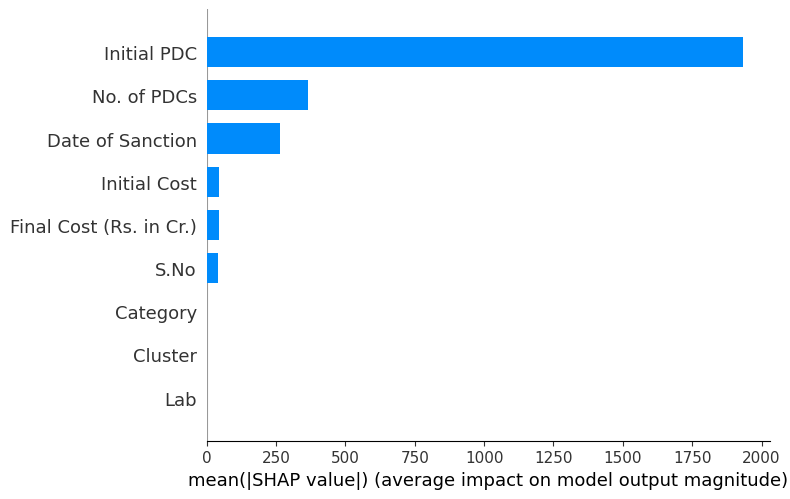

ValueError: visualize() can only display Explanation objects (or arrays of them)!

In [ ]:
import shap

# Create SHAP explainer
explainer = shap.Explainer(best_model)
shap_values = explainer(X)

# Summary plot
shap.summary_plot(shap_values, X, plot_type="bar")

# Detailed force plot for first prediction
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0], X.iloc[0])
